# Hydration Prediction — Final


## 1. Import Library

In [1]:
!pip install xgboost lightgbm imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
import os

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, LGBMRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    IsolationForest
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
MODEL_DIR = "model"
for sub in ["preprocessors", "classifiers", "regressors"]:
    os.makedirs(os.path.join(MODEL_DIR, sub), exist_ok=True)

print("Library siap.")

Library siap.


## 2. Load Data & EDA

In [3]:
df = pd.read_csv("Daily_Water_Intake.csv")
print(f"Shape: {df.shape}")
print(f"\nKolom: {df.columns.tolist()}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDistribusi label:")
print(df['Hydration Level'].value_counts())
print(f"\nStatistik deskriptif:")
df.describe()

Shape: (30000, 7)

Kolom: ['Age', 'Gender', 'Weight (kg)', 'Daily Water Intake (liters)', 'Physical Activity Level', 'Weather', 'Hydration Level']

Null values:
Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64

Distribusi label:
Hydration Level
Good    23915
Poor     6085
Name: count, dtype: int64

Statistik deskriptif:


,Age,Weight (kg),Daily Water Intake (liters)
count,30000.000000,30000.00000,30000.000000
mean,43.467667,76.84860,2.852444
std,14.998940,18.74494,0.835537
min,18.000000,45.00000,1.500000
25%,30.000000,61.00000,2.220000
50%,43.000000,77.00000,2.830000
75%,56.000000,93.00000,3.440000
max,69.000000,109.00000,5.430000


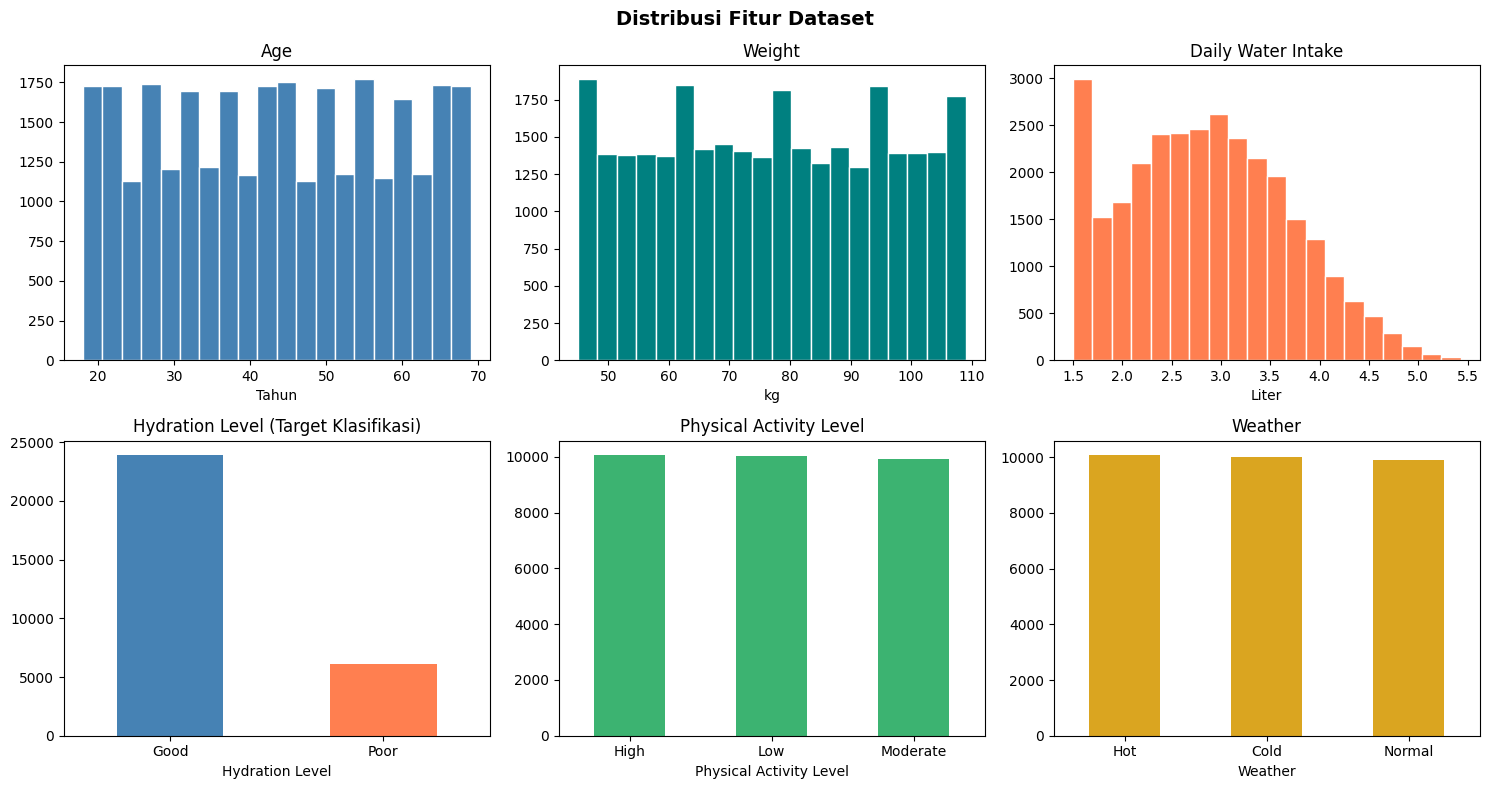

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribusi Fitur Dataset", fontsize=14, fontweight='bold')

axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title("Age"); axes[0,0].set_xlabel("Tahun")

axes[0,1].hist(df['Weight (kg)'], bins=20, color='teal', edgecolor='white')
axes[0,1].set_title("Weight"); axes[0,1].set_xlabel("kg")

axes[0,2].hist(df['Daily Water Intake (liters)'], bins=20, color='coral', edgecolor='white')
axes[0,2].set_title("Daily Water Intake"); axes[0,2].set_xlabel("Liter")

df['Hydration Level'].value_counts().plot(kind='bar', ax=axes[1,0], color=['steelblue','coral'])
axes[1,0].set_title("Hydration Level (Target Klasifikasi)"); axes[1,0].tick_params(rotation=0)

df['Physical Activity Level'].value_counts().plot(kind='bar', ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title("Physical Activity Level"); axes[1,1].tick_params(rotation=0)

df['Weather'].value_counts().plot(kind='bar', ax=axes[1,2], color='goldenrod')
axes[1,2].set_title("Weather"); axes[1,2].tick_params(rotation=0)

plt.tight_layout()
plt.show()

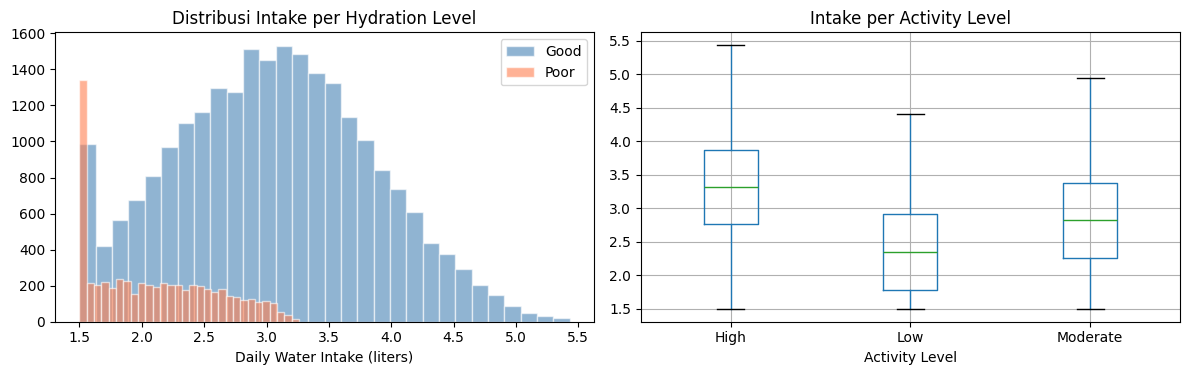

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi intake per label
for lbl, color in [('Good', 'steelblue'), ('Poor', 'coral')]:
    axes[0].hist(
        df[df['Hydration Level'] == lbl]['Daily Water Intake (liters)'],
        bins=30, alpha=0.6, label=lbl, color=color, edgecolor='white'
    )
axes[0].set_title("Distribusi Intake per Hydration Level")
axes[0].set_xlabel("Daily Water Intake (liters)")
axes[0].legend()

# Intake per activity
df.boxplot(column='Daily Water Intake (liters)', by='Physical Activity Level', ax=axes[1])
axes[1].set_title("Intake per Activity Level")
axes[1].set_xlabel("Activity Level")
plt.suptitle("")

plt.tight_layout()
plt.show()

## 3. Data Preparation & Outlier Removal

In [6]:
# Cleaning
df_clean = df.drop_duplicates()
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Outlier removal menggunakan IsolationForest pada fitur numerik asli
BASE_COLS = ['Age', 'Weight (kg)', 'Daily Water Intake (liters)']
iso  = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
mask = iso.fit_predict(df_clean[BASE_COLS]) == 1
df_clean = df_clean[mask].reset_index(drop=True)
print(f"Setelah outlier removal: {df_clean.shape[0]} baris ({mask.sum()/len(mask)*100:.1f}% retained)")

# Encode target klasifikasi
df_clean['label_bin'] = (df_clean['Hydration Level'] == 'Good').astype(int)

print(f"\nDistribusi label setelah cleaning:")
print(df_clean['Hydration Level'].value_counts())

Setelah outlier removal: 28772 baris (97.0% retained)

Distribusi label setelah cleaning:
Hydration Level
Good    22909
Poor     5863
Name: count, dtype: int64


In [7]:
# Definisi feature sets — tanpa feature engineering
CATEGORICAL = ['Gender', 'Physical Activity Level', 'Weather']

# Skenario 1: Klasifikasi — dengan intake
NUM_S1   = ['Age', 'Weight (kg)', 'Daily Water Intake (liters)']
COLS_S1  = NUM_S1 + CATEGORICAL
TARGET_S1 = 'label_bin'  # Hydration Level: Good=1, Poor=0

# Skenario 2: Regresi — tanpa intake
NUM_S2   = ['Age', 'Weight (kg)']
COLS_S2  = NUM_S2 + CATEGORICAL
TARGET_S2 = 'Daily Water Intake (liters)'

print("Feature sets:")
print(f"  S1 (Klasifikasi) : {COLS_S1}  → target: Hydration Level")
print(f"  S2 (Regresi)     : {COLS_S2}  → target: {TARGET_S2}")

Feature sets:
  S1 (Klasifikasi) : ['Age', 'Weight (kg)', 'Daily Water Intake (liters)', 'Gender', 'Physical Activity Level', 'Weather']  → target: Hydration Level
  S2 (Regresi)     : ['Age', 'Weight (kg)', 'Gender', 'Physical Activity Level', 'Weather']  → target: Daily Water Intake (liters)


## 4. Preprocessors

In [8]:
def build_preprocessor(num_cols):
    return ColumnTransformer(transformers=[
        ("num", RobustScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False), CATEGORICAL)
    ])

pre_s1 = build_preprocessor(NUM_S1)
pre_s2 = build_preprocessor(NUM_S2)
smote  = SMOTE(random_state=RANDOM_STATE)

print("Preprocessors siap.")

Preprocessors siap.


## 5. Skenario 1 — Klasifikasi (Dengan Intake)

In [9]:
X_s1 = df_clean[COLS_S1]
y_s1 = df_clean[TARGET_S1]

X_tr_s1, X_te_s1, y_tr_s1, y_te_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, stratify=y_s1, random_state=RANDOM_STATE
)

# Fit preprocessor
X_tr_s1_pre = pre_s1.fit_transform(X_tr_s1)
X_te_s1_pre = pre_s1.transform(X_te_s1)

# SMOTE untuk atasi imbalance
X_res_s1, y_res_s1 = smote.fit_resample(X_tr_s1_pre, y_tr_s1)
print(f"Setelah SMOTE: {X_res_s1.shape[0]} sampel training")

# Kandidat model
CLS_CANDIDATES = {
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "max_depth": [None, 5, 10],
         "max_features": ["sqrt", "log2"]}
    ),
    "XGBoost": (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                      use_label_encoder=False),
        {"n_estimators": [100, 200], "max_depth": [3, 5, 7],
         "learning_rate": [0.01, 0.05, 0.1],
         "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]}
    ),
    "LightGBM": (
        LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
        {"n_estimators": [100, 200], "max_depth": [-1, 5, 10],
         "learning_rate": [0.01, 0.05, 0.1],
         "num_leaves": [15, 31, 63], "subsample": [0.8, 1.0]}
    ),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cls_results = []
best_s1_model, best_s1_auc, best_s1_name = None, -np.inf, ""

print("="*60)
print(f"{'Model':<22} {'CV_AUC':>8} {'Test_AUC':>9} {'Acc':>7} {'F1':>7}")
print("="*60)

for name, (model, params) in CLS_CANDIDATES.items():
    gs = GridSearchCV(model, params, cv=skf, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_res_s1, y_res_s1)
    pred = gs.best_estimator_.predict(X_te_s1_pre)
    prob = gs.best_estimator_.predict_proba(X_te_s1_pre)[:, 1]
    acc  = accuracy_score(y_te_s1, pred)
    f1   = f1_score(y_te_s1, pred)
    auc  = roc_auc_score(y_te_s1, prob)
    cls_results.append({
        "Model": name, "CV_AUC": round(gs.best_score_, 4),
        "Test_AUC": round(auc, 4), "Accuracy": round(acc, 4),
        "F1": round(f1, 4), "Best_Params": gs.best_params_
    })
    print(f"{name:<22} {gs.best_score_:>8.4f} {auc:>9.4f} {acc:>7.4f} {f1:>7.4f}")
    if auc > best_s1_auc:
        best_s1_auc, best_s1_model, best_s1_name = auc, gs.best_estimator_, name

print("="*60)
print(f"✅ Best: {best_s1_name}  (AUC={best_s1_auc:.4f})")
df_cls = pd.DataFrame(cls_results).sort_values("Test_AUC", ascending=False)

Setelah SMOTE: 36654 sampel training
Model                    CV_AUC  Test_AUC     Acc      F1
RandomForest             0.9997    0.9986  0.9835  0.9896
XGBoost                  1.0000    1.0000  0.9969  0.9980
LightGBM                 1.0000    1.0000  0.9981  0.9988
✅ Best: XGBoost  (AUC=1.0000)


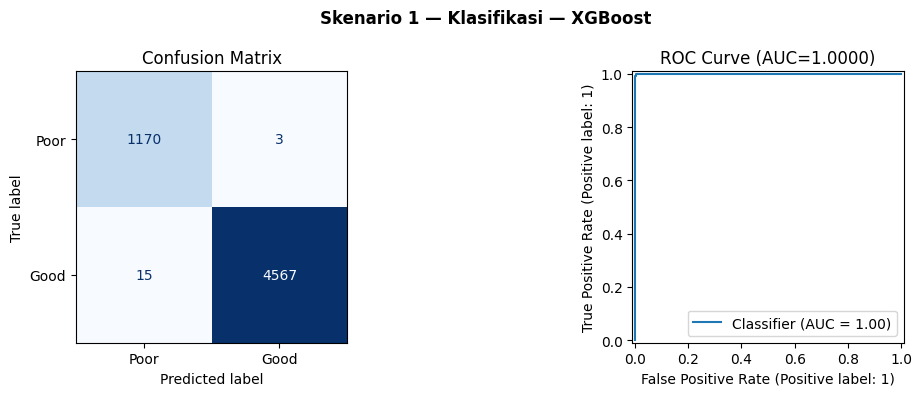

              precision    recall  f1-score   support

        Poor       0.99      1.00      0.99      1173
        Good       1.00      1.00      1.00      4582

    accuracy                           1.00      5755
   macro avg       0.99      1.00      1.00      5755
weighted avg       1.00      1.00      1.00      5755



In [10]:
# Visualisasi Skenario 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Skenario 1 — Klasifikasi — {best_s1_name}", fontweight='bold')

pred_s1 = best_s1_model.predict(X_te_s1_pre)
prob_s1 = best_s1_model.predict_proba(X_te_s1_pre)[:, 1]

ConfusionMatrixDisplay.from_predictions(
    y_te_s1, pred_s1, ax=axes[0],
    colorbar=False, cmap='Blues', display_labels=['Poor', 'Good']
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_te_s1, prob_s1, ax=axes[1])
axes[1].set_title(f"ROC Curve (AUC={roc_auc_score(y_te_s1, prob_s1):.4f})")

plt.tight_layout()
plt.show()
print(classification_report(y_te_s1, pred_s1, target_names=['Poor', 'Good']))

In [11]:
# Simpan model Skenario 1
joblib.dump(pre_s1, os.path.join(MODEL_DIR, "preprocessors", "preprocessor_s1.pkl"))
joblib.dump(best_s1_model, os.path.join(MODEL_DIR, "classifiers", "classifier_s1.pkl"))
print(f"✅ Saved: preprocessor_s1.pkl + classifier_s1.pkl  [{best_s1_name}]")

✅ Saved: preprocessor_s1.pkl + classifier_s1.pkl  [XGBoost]


## 6. Skenario 2 — Regresi (Tanpa Intake)

In [12]:
X_s2 = df_clean[COLS_S2]
y_s2 = df_clean[TARGET_S2]

X_tr_s2, X_te_s2, y_tr_s2, y_te_s2 = train_test_split(
    X_s2, y_s2, test_size=0.2, random_state=RANDOM_STATE
)

# Fit preprocessor
X_tr_s2_pre = pre_s2.fit_transform(X_tr_s2)
X_te_s2_pre = pre_s2.transform(X_te_s2)

# Kandidat model regresi
REG_CANDIDATES = {
    "RandomForest": (
        RandomForestRegressor(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "max_depth": [None, 5, 10]}
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1],
         "max_depth": [3, 5]}
    ),
    "LightGBM": (
        LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
        {"n_estimators": [100, 200], "max_depth": [-1, 5, 10],
         "learning_rate": [0.01, 0.05, 0.1],
         "num_leaves": [15, 31, 63]}
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
reg_results = []
best_s2_model, best_s2_r2, best_s2_name = None, -np.inf, ""

print("="*55)
print(f"{'Model':<22} {'CV_R2':>8} {'Test_R2':>8} {'RMSE':>7} {'MAE':>7}")
print("="*55)

for name, (model, params) in REG_CANDIDATES.items():
    gs = GridSearchCV(model, params, cv=kf, scoring="r2", n_jobs=-1)
    gs.fit(X_tr_s2_pre, y_tr_s2)
    pred = gs.best_estimator_.predict(X_te_s2_pre)
    r2   = r2_score(y_te_s2, pred)
    rmse = np.sqrt(mean_squared_error(y_te_s2, pred))
    mae  = mean_absolute_error(y_te_s2, pred)
    reg_results.append({
        "Model": name, "CV_R2": round(gs.best_score_, 4),
        "Test_R2": round(r2, 4), "RMSE": round(rmse, 4),
        "MAE": round(mae, 4), "Best_Params": gs.best_params_
    })
    print(f"{name:<22} {gs.best_score_:>8.4f} {r2:>8.4f} {rmse:>7.4f} {mae:>7.4f}")
    if r2 > best_s2_r2:
        best_s2_r2, best_s2_model, best_s2_name = r2, gs.best_estimator_, name

print("="*55)
print(f"✅ Best: {best_s2_name}  (Test R²={best_s2_r2:.4f})")
df_reg = pd.DataFrame(reg_results).sort_values("Test_R2", ascending=False)

Model                     CV_R2  Test_R2    RMSE     MAE
RandomForest             0.8709   0.8703  0.2848  0.2407
GradientBoosting         0.8758   0.8754  0.2791  0.2380
LightGBM                 0.8762   0.8757  0.2788  0.2374
✅ Best: LightGBM  (Test R²=0.8757)


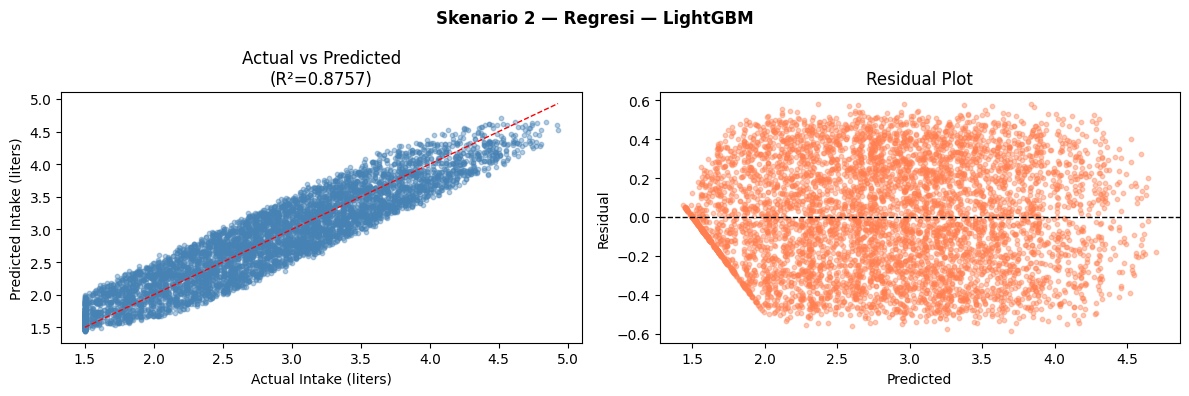

In [13]:
# Visualisasi Skenario 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Skenario 2 — Regresi — {best_s2_name}", fontweight='bold')

pred_s2 = best_s2_model.predict(X_te_s2_pre)

axes[0].scatter(y_te_s2, pred_s2, alpha=0.4, s=10, color='steelblue')
lims = [y_te_s2.min(), y_te_s2.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel("Actual Intake (liters)")
axes[0].set_ylabel("Predicted Intake (liters)")
axes[0].set_title(f"Actual vs Predicted\n(R²={best_s2_r2:.4f})")

residuals = y_te_s2 - pred_s2
axes[1].scatter(pred_s2, residuals, alpha=0.4, s=10, color='coral')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

In [14]:
# Simpan model Skenario 2
joblib.dump(pre_s2, os.path.join(MODEL_DIR, "preprocessors", "preprocessor_s2.pkl"))
joblib.dump(best_s2_model, os.path.join(MODEL_DIR, "regressors", "regressor_s2.pkl"))
print(f"✅ Saved: preprocessor_s2.pkl + regressor_s2.pkl  [{best_s2_name}]")

✅ Saved: preprocessor_s2.pkl + regressor_s2.pkl  [LightGBM]


## 7. Final Summary & Metadata

In [15]:
print("="*60)
print("LEADERBOARD — SKENARIO 1 (Klasifikasi dengan Intake)")
print("="*60)
print(df_cls[["Model", "CV_AUC", "Test_AUC", "Accuracy", "F1"]].to_string(index=False))

print("\n" + "="*60)
print("LEADERBOARD — SKENARIO 2 (Regresi tanpa Intake)")
print("="*60)
print(df_reg[["Model", "CV_R2", "Test_R2", "RMSE", "MAE"]].to_string(index=False))

LEADERBOARD — SKENARIO 1 (Klasifikasi dengan Intake)
       Model  CV_AUC  Test_AUC  Accuracy     F1
     XGBoost  1.0000    1.0000    0.9969 0.9980
    LightGBM  1.0000    1.0000    0.9981 0.9988
RandomForest  0.9997    0.9986    0.9835 0.9896

LEADERBOARD — SKENARIO 2 (Regresi tanpa Intake)
           Model  CV_R2  Test_R2   RMSE    MAE
        LightGBM 0.8762   0.8757 0.2788 0.2374
GradientBoosting 0.8758   0.8754 0.2791 0.2380
    RandomForest 0.8709   0.8703 0.2848 0.2407
